In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Fetch actuals
actuals_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom=2024-01-01&settlementDateTo=2024-01-31&fuelType=WIND&format=json"
actuals = requests.get(actuals_url).json()
df_actuals = pd.DataFrame(actuals)[['startTime', 'generation']]
df_actuals.columns = ['time', 'actual']
df_actuals['time'] = pd.to_datetime(df_actuals['time'])
print("✅ Actuals:", len(df_actuals), "rows")

# Fetch forecasts
forecasts_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom=2024-01-01T00:00:00Z&publishDateTimeTo=2024-01-31T23:59:59Z&format=json"
forecasts = requests.get(forecasts_url).json()
df_forecasts = pd.DataFrame(forecasts)[['startTime', 'publishTime', 'generation']]
df_forecasts.columns = ['time', 'publishTime', 'forecast']
df_forecasts['time'] = pd.to_datetime(df_forecasts['time'])
df_forecasts['publishTime'] = pd.to_datetime(df_forecasts['publishTime'])
print("✅ Forecasts:", len(df_forecasts), "rows")

✅ Actuals: 1488 rows
✅ Forecasts: 12152 rows


In [3]:
# Calculate forecast horizon in hours
df_forecasts['horizon_hours'] = (df_forecasts['time'] - df_forecasts['publishTime']).dt.total_seconds() / 3600

# Filter 0-48 hours
df_forecasts = df_forecasts[(df_forecasts['horizon_hours'] >= 0) & (df_forecasts['horizon_hours'] <= 48)]

# Merge with actuals
df = pd.merge(df_forecasts, df_actuals, on='time', how='inner')
df['error'] = df['forecast'] - df['actual']
df['abs_error'] = df['error'].abs()

print("✅ Merged rows:", len(df))
print(df.head())

✅ Merged rows: 9200
                       time               publishTime  forecast  \
0 2024-01-31 23:00:00+00:00 2024-01-31 22:30:00+00:00     16909   
1 2024-01-31 21:00:00+00:00 2024-01-31 18:30:00+00:00     17912   
2 2024-01-31 22:00:00+00:00 2024-01-31 18:30:00+00:00     17670   
3 2024-01-31 23:00:00+00:00 2024-01-31 18:30:00+00:00     17275   
4 2024-01-31 21:00:00+00:00 2024-01-31 15:30:00+00:00     17887   

   horizon_hours  actual  error  abs_error  
0            0.5   14595   2314       2314  
1            2.5   15757   2155       2155  
2            3.5   15490   2180       2180  
3            4.5   14595   2680       2680  
4            5.5   15757   2130       2130  


In [4]:
print("=== FORECAST ERROR ANALYSIS ===")
print(f"Mean Error:   {df['error'].mean():.0f} MW")
print(f"Median Error: {df['error'].median():.0f} MW")
print(f"Mean Abs Error: {df['abs_error'].mean():.0f} MW")
print(f"P99 Error:    {df['abs_error'].quantile(0.99):.0f} MW")
print(f"Max Error:    {df['abs_error'].max():.0f} MW")

=== FORECAST ERROR ANALYSIS ===
Mean Error:   1407 MW
Median Error: 1318 MW
Mean Abs Error: 2072 MW
P99 Error:    7189 MW
Max Error:    18076 MW


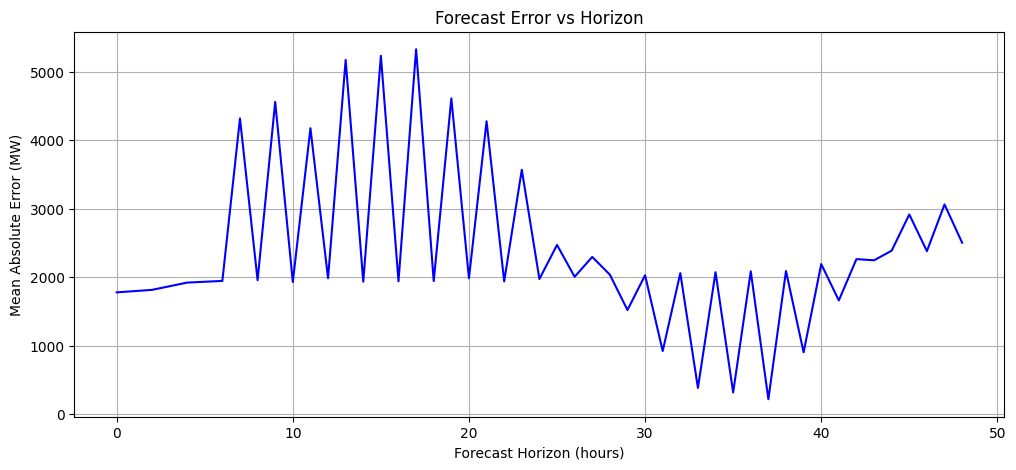

In [5]:
# Group by horizon (rounded to nearest hour)
df['horizon_rounded'] = df['horizon_hours'].round()
horizon_error = df.groupby('horizon_rounded')['abs_error'].mean()

plt.figure(figsize=(12,5))
plt.plot(horizon_error.index, horizon_error.values, color='blue')
plt.xlabel('Forecast Horizon (hours)')
plt.ylabel('Mean Absolute Error (MW)')
plt.title('Forecast Error vs Horizon')
plt.grid(True)
plt.show()

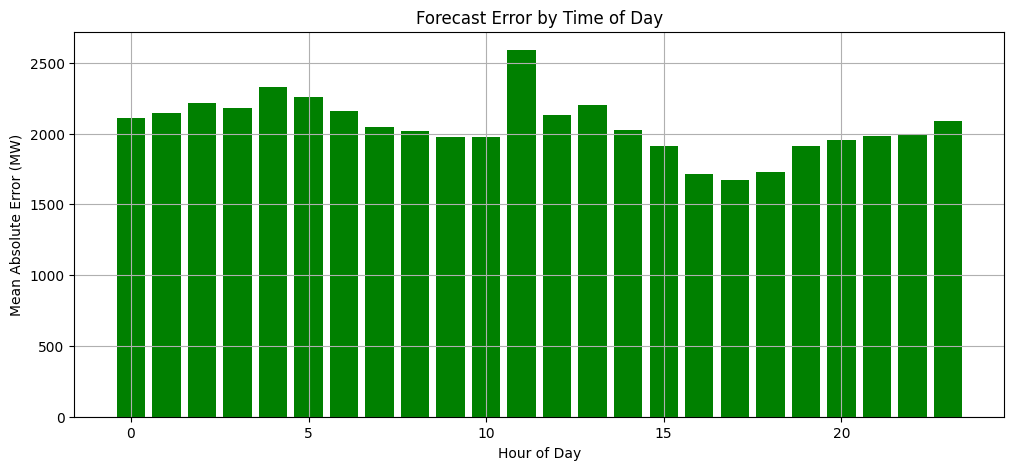

In [6]:
df['hour'] = df['time'].dt.hour
hourly_error = df.groupby('hour')['abs_error'].mean()

plt.figure(figsize=(12,5))
plt.bar(hourly_error.index, hourly_error.values, color='green')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Absolute Error (MW)')
plt.title('Forecast Error by Time of Day')
plt.grid(True)
plt.show()